In [9]:
import torch 
from matplotlib import pyplot as plt

# First, define some utility work to map phi -> theta

In [2]:
# utility function to calculate weight indices 
def init_(in_channels, out_channels, hidden_channels, layers):

    theta_size = (in_channels*hidden_channels + hidden_channels) + \
                    (hidden_channels*hidden_channels + hidden_channels)*layers + \
                    (hidden_channels*out_channels + out_channels)
    
    W_indices = [torch.arange(in_channels*hidden_channels)]
    offset = in_channels*hidden_channels
    for i in range(layers): 
        W_indices.append( torch.arange(offset, offset + hidden_channels*hidden_channels) )
        offset += hidden_channels*hidden_channels
    W_indices.append(torch.arange(offset, offset + hidden_channels*out_channels))
    offset += hidden_channels*out_channels 

    bias_indices = [] 
    for i in range(layers+1): 
        bias_indices.append( torch.arange(offset, offset + hidden_channels))
        offset += hidden_channels 

    bias_indices.append( torch.arange(offset, offset + out_channels) )
    offset += out_channels

    assert theta_size == offset, f'expected theta_size ({theta_size}) to be the same as final offset ({offset})'

    return theta_size, W_indices, bias_indices

# Next, let's define a HyperNet using a MLP architecture 

In [7]:
class HyperNetMLP(torch.nn.Module): 
    def __init__(self, in_channels, out_channels, hidden_channels, layers, stochastic_channels, width): 
        super().__init__()
        self.in_channels            = in_channels
        self.out_channels           = out_channels 
        self.hidden_channels        = hidden_channels
        self.layers                 = layers
        self.stochastic_channels    = stochastic_channels
        self.width                  = width
        self.nonlin                 = torch.nn.ReLU()

        theta_size, W_indices, bias_indices = init_(in_channels, out_channels, hidden_channels, layers)

        self.W_sizes = [(in_channels, hidden_channels)] + [(hidden_channels, hidden_channels) for _ in range(layers)] + [(hidden_channels, out_channels)]
        
        for i,Widx in enumerate(W_indices): self.register_buffer(f'W{i}', Widx)
        for i,Bidx in enumerate(bias_indices): self.register_buffer(f'B{i}', Bidx)
        
        self.f_phi = torch.nn.Sequential(torch.nn.Linear(stochastic_channels, width, bias=False), 
                                         torch.nn.ReLU(), 
                                         torch.nn.Linear(width, theta_size, bias=False))

        self.register_buffer('mu', torch.zeros((stochastic_channels), requires_grad=False))
        self.register_buffer('std', torch.ones((stochastic_channels), requires_grad=False))

    def forward(self, x, samples=10): 
        x = x.T.unsqueeze(0).expand(samples, -1, -1) # x size: (batch, in_channels)

        m = torch.distributions.Normal(self.mu, self.std) # could use other distributions as well! 
        z = m.sample((samples,))
        theta = self.f_phi(z)

        for i in range(self.layers + 1): 
            W = theta[:, getattr(self, f'W{i}')].view(-1, *self.W_sizes[i]) # size (samples, channels_in, channels_out)
            B = theta[:, getattr(self, f'B{i}')].unsqueeze(2)               # size (samples, 1, channels_out)
            x = torch.matmul(W.permute(0,2,1), x) + B                       # size (samples, )
            x = self.nonlin(x)

        W = theta[:, getattr(self, f'W{self.layers+1}')].view(-1, *self.W_sizes[self.layers+1])
        B = theta[:, getattr(self, f'B{self.layers+1}')].view(-1, self.out_channels,1)
        x = torch.matmul(W.permute(0,2,1), x) + B
        x = x.permute(0,2,1)
        return x


# Now let's sample some MLP functions

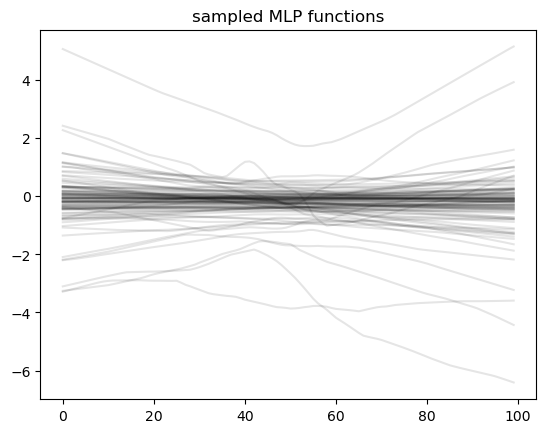

In [14]:
x = torch.linspace(-3,3,100)
model = HyperNetMLP(in_channels=1, out_channels=1, hidden_channels=25, layers=2, stochastic_channels=10, width=25)
yhat = model(x, samples=100) 

plt.figure()
plt.title('sampled MLP functions')
for f in yhat.detach().cpu().numpy():
    plt.plot(f, 'k-', alpha=0.1)
plt.show()